In [1]:
import pandas as pd

dataset_path = "/kaggle/input/datasets/alikaanersoy/unsw-nb15-project-data/CSV Files/Training and Testing Sets/UNSW_NB15_training-set.csv"
network_data = pd.read_csv(dataset_path)

print(network_data.shape)

(175341, 45)


In [2]:
print(network_data.info())
print(network_data['label'].value_counts())
print(network_data['attack_cat'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [3]:
from sklearn.preprocessing import LabelEncoder

x_train = network_data.drop(['id', 'attack_cat', 'label'], axis=1)
y_train = network_data['label']

categorical_cols = ['proto', 'service', 'state']
label_encoder = LabelEncoder()

for col in categorical_cols:
    x_train[col] = label_encoder.fit_transform(x_train[col].astype(str))

print(x_train[['proto', 'service', 'state']].head())

   proto  service  state
0    113        0      2
1    113        0      2
2    113        0      2
3    113        3      2
4    113        0      2


In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns)

print(x_train_scaled_df.head())

        dur     proto   service     state     spkts     dpkts    sbytes  \
0 -0.191029  0.151809 -0.702307 -0.409218 -0.104456 -0.135769 -0.049134   
1 -0.109485  0.151809 -0.702307 -0.409218 -0.046014  0.172599 -0.046410   
2  0.040699  0.151809 -0.702307 -0.409218 -0.089845 -0.026933 -0.048527   
3  0.049729  0.151809  0.599130 -0.409218 -0.060624 -0.063212 -0.047016   
4 -0.140417  0.151809 -0.702307 -0.409218 -0.075235 -0.117630 -0.047554   

     dbytes      rate      sttl  ...  ct_dst_ltm  ct_src_dport_ltm  \
0 -0.102726 -0.576371  0.703839  ...   -0.645013         -0.544736   
1  0.188544 -0.576345 -1.141901  ...   -0.645013         -0.544736   
2 -0.012133 -0.576734 -1.141901  ...   -0.520827         -0.544736   
3 -0.098563 -0.576737 -1.141901  ...   -0.520827         -0.544736   
4 -0.102057 -0.576617  0.723268  ...   -0.520827         -0.420468   

   ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0         -0.554373       -0.705529     -0.118590   -0.118590  

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(x_train_scaled_df, y_train, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_split, y_train_split)

predictions = rf_model.predict(x_val_split)

print(accuracy_score(y_val_split, predictions))
print(classification_report(y_val_split, predictions))

0.9593373064529926
              precision    recall  f1-score   support

           0       0.96      0.92      0.93     11169
           1       0.96      0.98      0.97     23900

    accuracy                           0.96     35069
   macro avg       0.96      0.95      0.95     35069
weighted avg       0.96      0.96      0.96     35069



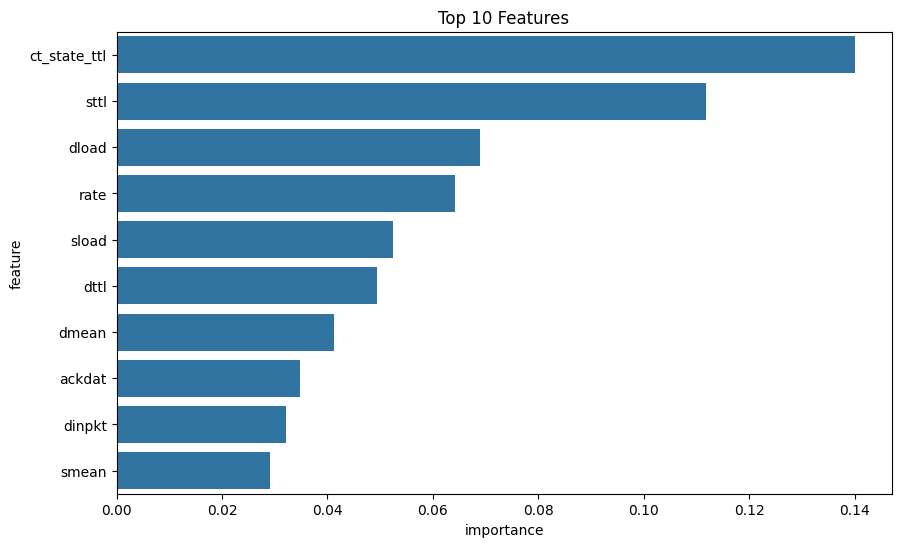

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_importances = rf_model.feature_importances_
features_df = pd.DataFrame({
    'feature': x_train_scaled_df.columns,
    'importance': feature_importances
})

features_df = features_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=features_df)
plt.title('Top 10 Features')
plt.show()

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

test_data_path = "/kaggle/input/datasets/alikaanersoy/unsw-nb15-project-data/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv"
test_data = pd.read_csv(test_data_path)

x_unseen = test_data.drop(['id', 'attack_cat', 'label'], axis=1)
y_unseen = test_data['label']

for col in categorical_cols:
    x_unseen[col] = label_encoder.fit_transform(x_unseen[col].astype(str))

x_unseen_scaled = scaler.transform(x_unseen)
x_unseen_scaled_df = pd.DataFrame(x_unseen_scaled, columns=x_unseen.columns)

unseen_predictions = rf_model.predict(x_unseen_scaled_df)

print(accuracy_score(y_unseen, unseen_predictions))
print(classification_report(y_unseen, unseen_predictions))

0.8689452460768595
              precision    recall  f1-score   support

           0       0.98      0.73      0.83     37000
           1       0.82      0.99      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332



/tmp/ipykernel_57/1031029426.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_dataframe, palette="viridis")


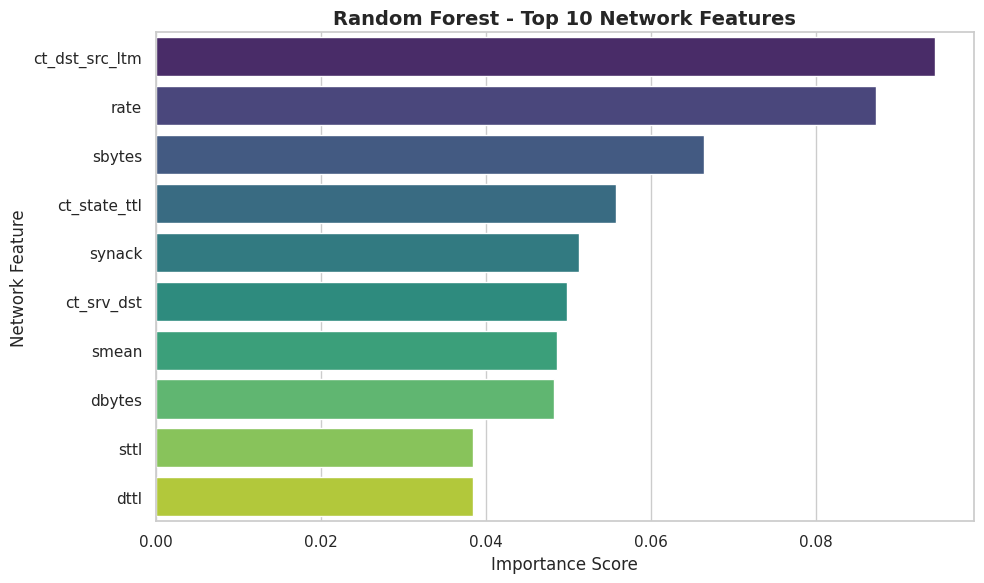

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


network_data = pd.read_csv("/kaggle/input/datasets/alikaanersoy/unsw-nb15-project-data/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv")
encoder = LabelEncoder()

categorical_columns = ['proto', 'service', 'state']
for column in categorical_columns:
    network_data[column] = encoder.fit_transform(network_data[column].astype(str))

# HATA ÇÖZÜMÜ: Metin içeren 'attack_cat' sütunu da analizden (features) çıkarıldı.
features = network_data.drop(['id', 'label', 'attack_cat'], axis=1, errors='ignore')
target = network_data['label']

forest_model = RandomForestClassifier(n_estimators=20, random_state=42)
forest_model.fit(features, target)

feature_importances = forest_model.feature_importances_
feature_names = features.columns

importance_dataframe = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_dataframe = importance_dataframe.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(x='Importance', y='Feature', data=importance_dataframe, palette="viridis")

plt.title('Random Forest - Top 10 Network Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Network Feature', fontsize=12)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

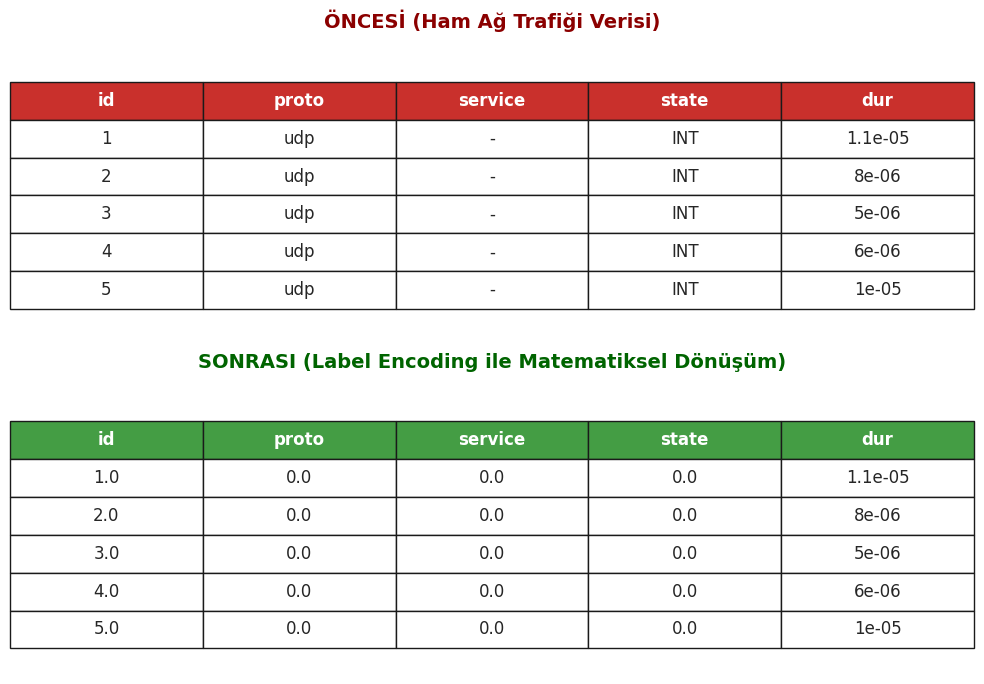

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

network_data = pd.read_csv("/kaggle/input/datasets/alikaanersoy/unsw-nb15-project-data/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv")

cols_to_show = ['id', 'proto', 'service', 'state', 'dur']
raw_df = network_data[cols_to_show].head(5).copy()

processed_df = raw_df.copy()
encoder = LabelEncoder()

for col in ['proto', 'service', 'state']:
    processed_df[col] = encoder.fit_transform(processed_df[col].astype(str))

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.patch.set_visible(False)

axes[0].axis('off')
axes[0].set_title('ÖNCESİ (Ham Ağ Trafiği Verisi)', fontweight="bold", color="darkred", fontsize=14, pad=20)
table_top = axes[0].table(cellText=raw_df.values, colLabels=raw_df.columns, loc='center', cellLoc='center')
table_top.auto_set_font_size(False)
table_top.set_fontsize(12)
table_top.scale(1, 2)

axes[1].axis('off')
axes[1].set_title('SONRASI (Label Encoding ile Matematiksel Dönüşüm)', fontweight="bold", color="darkgreen", fontsize=14, pad=20)
table_bottom = axes[1].table(cellText=processed_df.values, colLabels=processed_df.columns, loc='center', cellLoc='center')
table_bottom.auto_set_font_size(False)
table_bottom.set_fontsize(12)
table_bottom.scale(1, 2)

for key, cell in table_top.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#c9302c') 
        
for key, cell in table_bottom.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#449d44')

plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.savefig("veri_on_isleme.png", dpi=300, bbox_inches="tight")
plt.show()

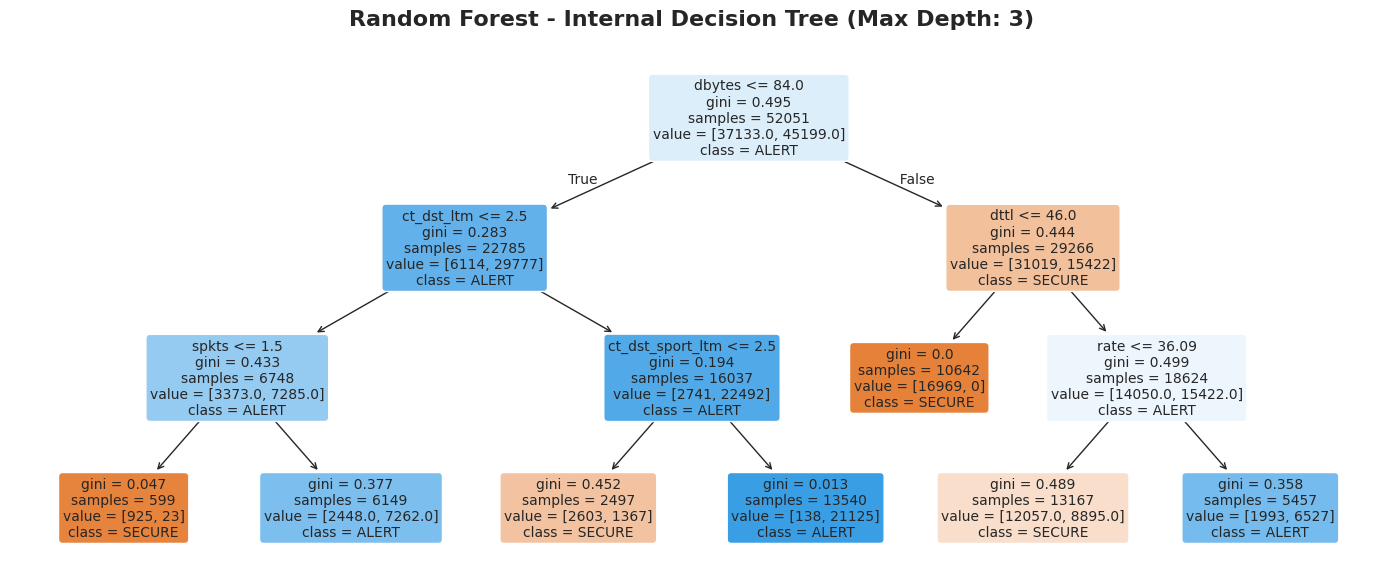

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

network_data = pd.read_csv("/kaggle/input/datasets/alikaanersoy/unsw-nb15-project-data/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv")
encoder = LabelEncoder()

categorical_columns = ['proto', 'service', 'state']
for column in categorical_columns:
    network_data[column] = encoder.fit_transform(network_data[column].astype(str))

features = network_data.drop(['id', 'label', 'attack_cat'], axis=1, errors='ignore')
target = network_data['label']

forest_model = RandomForestClassifier(n_estimators=20, max_depth=3, random_state=42)
forest_model.fit(features, target)

single_tree = forest_model.estimators_[0]

plt.figure(figsize=(14, 6))
plot_tree(
    single_tree, 
    feature_names=features.columns, 
    class_names=["SECURE", "ALERT"], 
    filled=True, 
    rounded=True, 
    fontsize=10,
    proportion=False
)
plt.title("Random Forest - Internal Decision Tree (Max Depth: 3)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("random_forest_tree.png", dpi=300)
plt.show()

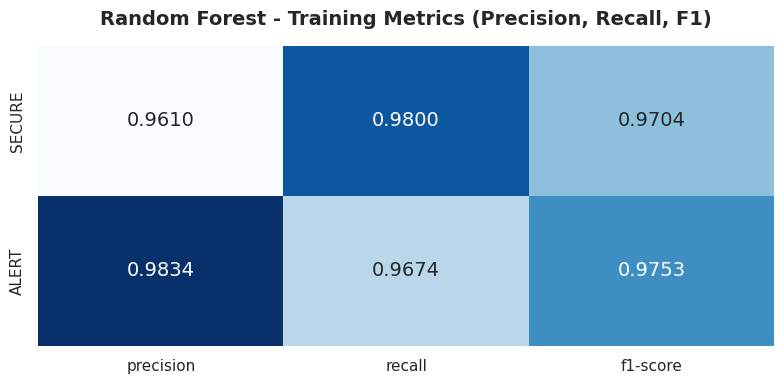

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

network_data = pd.read_csv("/kaggle/input/datasets/alikaanersoy/unsw-nb15-project-data/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv")
encoder = LabelEncoder()

categorical_columns = ['proto', 'service', 'state']
for column in categorical_columns:
    network_data[column] = encoder.fit_transform(network_data[column].astype(str))

features = network_data.drop(['id', 'label', 'attack_cat'], axis=1, errors='ignore')
target = network_data['label']

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

forest_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
forest_model.fit(features_train, target_train)

predictions = forest_model.predict(features_test)
report_dictionary = classification_report(target_test, predictions, target_names=["SECURE", "ALERT"], output_dict=True)
report_dataframe = pd.DataFrame(report_dictionary).iloc[:-1, :2].T

plt.figure(figsize=(8, 4))
sns.heatmap(report_dataframe, annot=True, cmap="Blues", fmt=".4f", cbar=False, annot_kws={"size": 14})
plt.title("Random Forest - Training Metrics (Precision, Recall, F1)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("training_metrics.png", dpi=300)
plt.show()

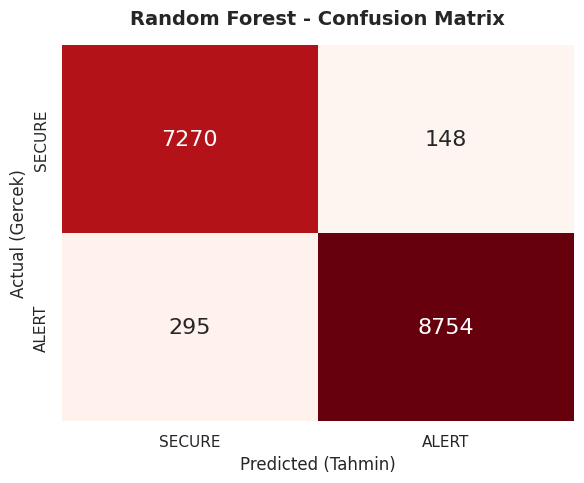

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

network_data = pd.read_csv("/kaggle/input/datasets/alikaanersoy/unsw-nb15-project-data/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv")
encoder = LabelEncoder()

categorical_columns = ['proto', 'service', 'state']
for column in categorical_columns:
    network_data[column] = encoder.fit_transform(network_data[column].astype(str))

features = network_data.drop(['id', 'label', 'attack_cat'], axis=1, errors='ignore')
target = network_data['label']

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

forest_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
forest_model.fit(features_train, target_train)

predictions = forest_model.predict(features_test)
matrix_data = confusion_matrix(target_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_data, annot=True, fmt="d", cmap="Reds", cbar=False, annot_kws={"size": 16}, xticklabels=["SECURE", "ALERT"], yticklabels=["SECURE", "ALERT"])
plt.title("Random Forest - Confusion Matrix", fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual (Gercek)', fontsize=12)
plt.xlabel('Predicted (Tahmin)', fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()